# Chapter 1 ASIC XGBoost Recalibration Review

This notebook reruns post hoc recalibration from saved ASIC baseline prediction artifacts only.
It fits recalibration on the validation split, applies the fitted mappings to test, and compares raw XGBoost, recalibrated XGBoost, and logistic regression.

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

try:
    from IPython.display import Image, Markdown, display
except ImportError:
    class Markdown(str):
        pass

    class Image:
        def __init__(self, filename: str):
            self.filename = filename

        def __repr__(self) -> str:
            return f"Image(filename={self.filename!r})"

    def display(*objects):
        for obj in objects:
            print(obj)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from chapter1_mortality_decomposition.xgboost_recalibration import (
    DEFAULT_BASELINE_ARTIFACT_ROOT,
    DEFAULT_RECALIBRATION_OUTPUT_DIR,
    run_asic_xgboost_recalibration,
)

PROJECT_ROOT

PosixPath('/Users/joanameyer/repository/1-mortality-decomposition')

## Artifact Loading And Recalibration Run

In [2]:
input_root = PROJECT_ROOT / DEFAULT_BASELINE_ARTIFACT_ROOT
output_dir = PROJECT_ROOT / DEFAULT_RECALIBRATION_OUTPUT_DIR

result = run_asic_xgboost_recalibration(
    input_root=input_root,
    output_dir=output_dir,
)

display(Markdown(f"**Input root:** `{result.input_root}`  \n**Output directory:** `{result.output_dir}`"))
display(Markdown(f"**Horizons processed:** `{', '.join(str(h) for h in result.horizons_processed)}`"))

status_rows = []
for horizon_result in result.horizon_results:
    row = {"horizon_h": horizon_result.horizon_h}
    for method_name, status in sorted(horizon_result.method_statuses.items()):
        row[f"{method_name}_status"] = status
    status_rows.append(row)
pd.DataFrame(status_rows).sort_values("horizon_h").reset_index(drop=True)

**Input root:** `/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/baselines/asic/primary_medians`  
**Output directory:** `/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/recalibration/asic/primary_medians/xgboost`

**Horizons processed:** `8, 16, 24, 48, 72`

,horizon_h,isotonic_status,platt_status
0,8,fit,fit
1,16,fit,fit
2,24,fit,fit
3,48,fit,fit
4,72,fit,fit


## Metric Comparison

In [3]:
metrics = pd.read_csv(result.combined_comparison_metrics_path)
metric_columns = [
    "horizon_h",
    "model_variant",
    "split",
    "sample_count",
    "event_count",
    "event_rate",
    "auroc",
    "auprc",
    "calibration_intercept",
    "calibration_slope",
    "brier_score",
    "mean_predicted_risk",
    "notes",
]

validation_metrics = (
    metrics.loc[metrics["split"].eq("validation"), metric_columns]
    .sort_values(["horizon_h", "model_variant"])
    .reset_index(drop=True)
)
test_metrics = (
    metrics.loc[metrics["split"].eq("test"), metric_columns]
    .sort_values(["horizon_h", "model_variant"])
    .reset_index(drop=True)
)

display(Markdown("### Validation Metrics"))
display(validation_metrics)
display(Markdown("### Test Metrics"))
display(test_metrics)

### Validation Metrics

,horizon_h,model_variant,split,sample_count,event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,brier_score,mean_predicted_risk,notes
0,8,logistic_regression,validation,244,2,0.008197,0.419421,0.011898,-5.880084,-0.170403,0.011678,0.015178,reference_saved_logistic_predictions
1,8,xgboost_isotonic,validation,244,2,0.008197,0.746901,0.022477,-0.139529,0.968358,0.008030,0.008197,recalibrated_saved_xgboost_predictions; fit_sp...
2,8,xgboost_platt,validation,244,2,0.008197,0.551653,0.022477,-0.198775,0.958665,0.008127,0.008206,recalibrated_saved_xgboost_predictions; fit_sp...
3,8,xgboost_raw,validation,244,2,0.008197,0.551653,0.022477,-4.054148,0.137427,0.010305,0.016739,reference_saved_xgboost_predictions
4,16,logistic_regression,validation,243,4,0.016461,0.654812,0.058796,-2.392905,0.387449,0.017934,0.024043,reference_saved_logistic_predictions
5,16,xgboost_isotonic,validation,243,4,0.016461,0.689854,0.026281,-0.127380,0.965099,0.016040,0.016461,recalibrated_saved_xgboost_predictions; fit_sp...
6,16,xgboost_platt,validation,243,4,0.016461,0.573222,0.023582,-0.230487,0.943873,0.016189,0.016474,recalibrated_saved_xgboost_predictions; fit_sp...
7,16,xgboost_raw,validation,243,4,0.016461,0.573222,0.023582,-3.798413,0.060936,0.021675,0.028642,reference_saved_xgboost_predictions
8,24,logistic_regression,validation,242,6,0.024793,0.740819,0.115801,-1.476574,0.630244,0.025735,0.038195,reference_saved_logistic_predictions
9,24,xgboost_isotonic,validation,242,6,0.024793,0.633828,0.035863,-0.187699,0.946721,0.024015,0.024793,recalibrated_saved_xgboost_predictions; fit_sp...


### Test Metrics

,horizon_h,model_variant,split,sample_count,event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,brier_score,mean_predicted_risk,notes
0,8,logistic_regression,test,235,0,0.0,NaN,NaN,NaN,NaN,0.000970,0.009268,auroc_unavailable_single_class; auprc_unavaila...
1,8,xgboost_isotonic,test,235,0,0.0,NaN,NaN,NaN,NaN,0.000182,0.008656,auroc_unavailable_single_class; auprc_unavaila...
2,8,xgboost_platt,test,235,0,0.0,NaN,NaN,NaN,NaN,0.000074,0.008420,auroc_unavailable_single_class; auprc_unavaila...
3,8,xgboost_raw,test,235,0,0.0,NaN,NaN,NaN,NaN,0.000938,0.013524,auroc_unavailable_single_class; auprc_unavaila...
4,16,logistic_regression,test,231,0,0.0,NaN,NaN,NaN,NaN,0.000906,0.016149,auroc_unavailable_single_class; auprc_unavaila...
5,16,xgboost_isotonic,test,231,0,0.0,NaN,NaN,NaN,NaN,0.000487,0.018730,auroc_unavailable_single_class; auprc_unavaila...
6,16,xgboost_platt,test,231,0,0.0,NaN,NaN,NaN,NaN,0.000286,0.016811,auroc_unavailable_single_class; auprc_unavaila...
7,16,xgboost_raw,test,231,0,0.0,NaN,NaN,NaN,NaN,0.005054,0.035261,auroc_unavailable_single_class; auprc_unavaila...
8,24,logistic_regression,test,227,0,0.0,NaN,NaN,NaN,NaN,0.002229,0.027543,auroc_unavailable_single_class; auprc_unavaila...
9,24,xgboost_isotonic,test,227,0,0.0,NaN,NaN,NaN,NaN,0.000885,0.027334,auroc_unavailable_single_class; auprc_unavaila...


In [4]:
test_brier_summary = (
    test_metrics[
        ["horizon_h", "model_variant", "event_rate", "mean_predicted_risk", "brier_score"]
    ]
    .pivot(index="horizon_h", columns="model_variant", values=["mean_predicted_risk", "brier_score"])
    .sort_index()
)
test_brier_summary

mean_predicted_risk                                             \
model_variant logistic_regression xgboost_isotonic xgboost_platt xgboost_raw   
horizon_h                                                                      
8                        0.009268         0.008656      0.008420    0.013524   
16                       0.016149         0.018730      0.016811    0.035261   
24                       0.027543         0.027334      0.024962    0.052053   
48                       0.064944         0.058503      0.054535    0.179592   
72                       0.092108         0.107603      0.099393    0.223645   

                      brier_score                                             
model_variant logistic_regression xgboost_isotonic xgboost_platt xgboost_raw  
horizon_h                                                                     
8                        0.000970         0.000182      0.000074    0.000938  
16                       0.000906         0.000487      0.000286    0.005054  
24                       0.002229         0.000885      0.000623    0.008131  
48                       0.007373         0.004116      0.003109    0.068816  
72                       0.015018         0.018387      0.014124    0.104581

## Reliability Visualization

### Cross-horizon summary figure

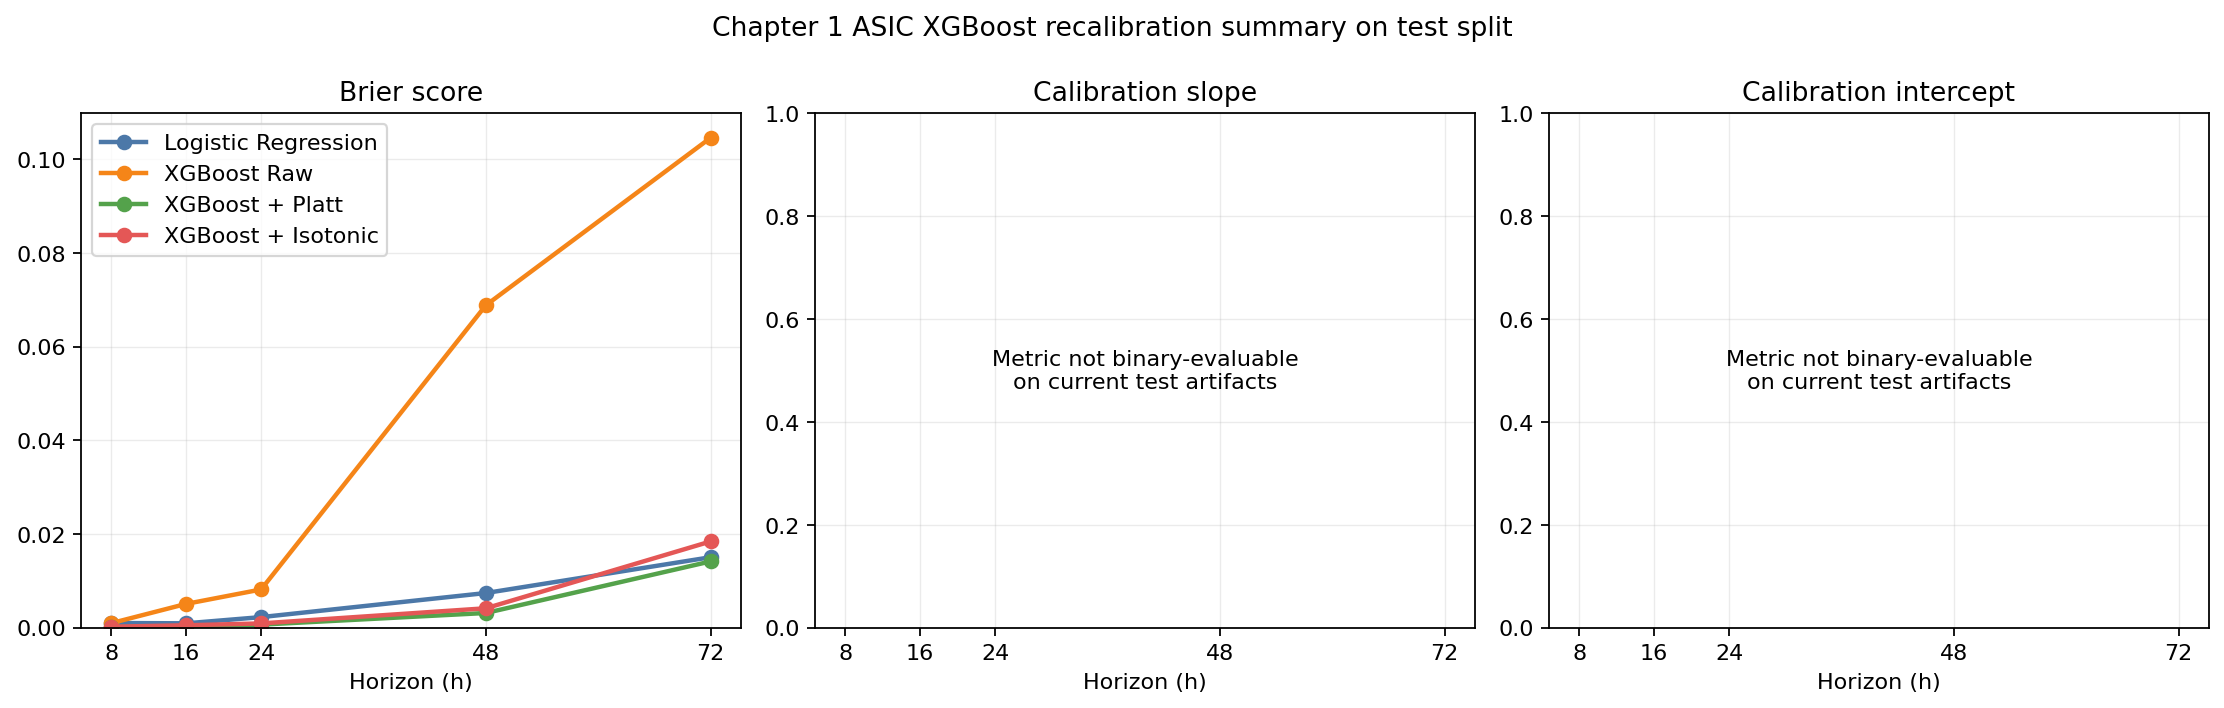

### Horizon 8h

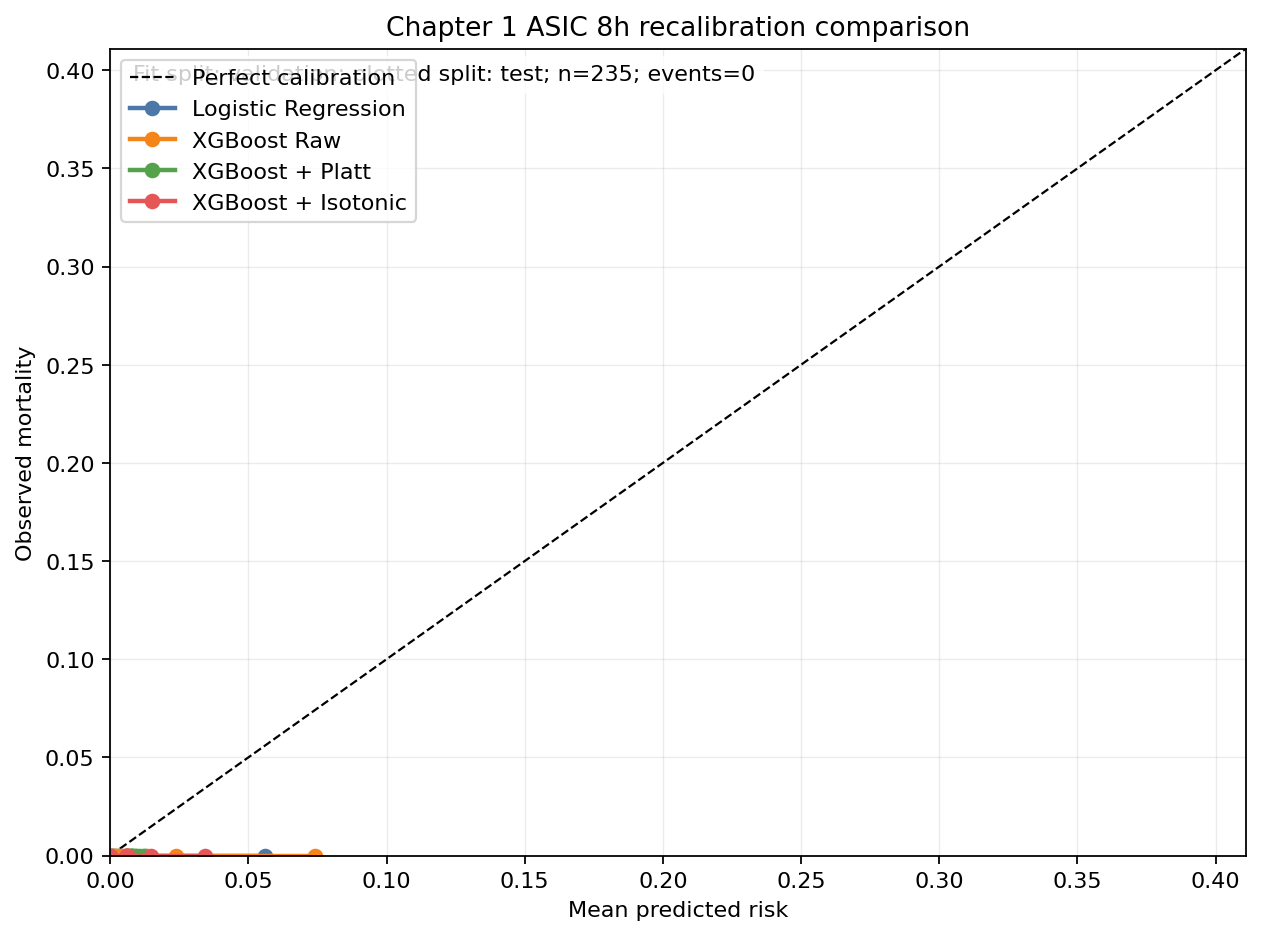

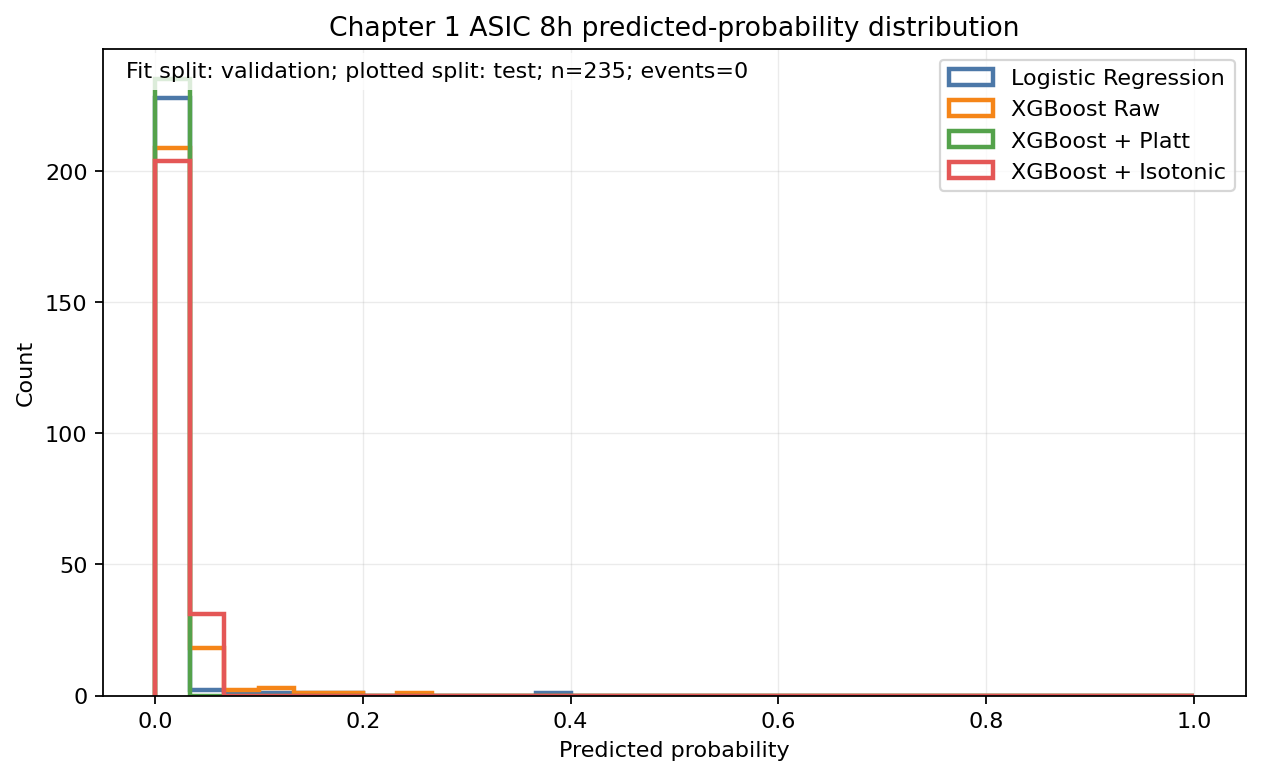

### Horizon 16h

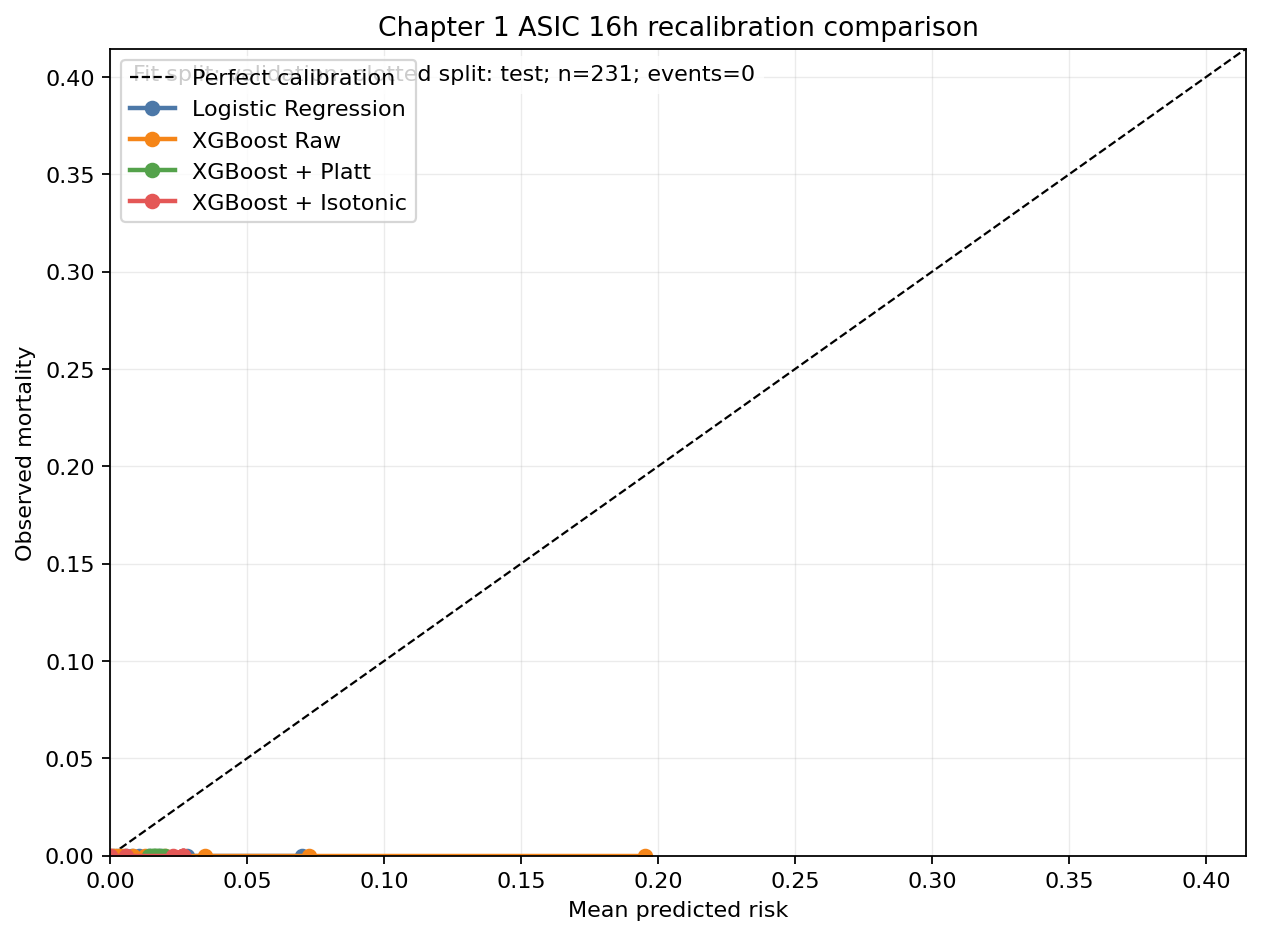

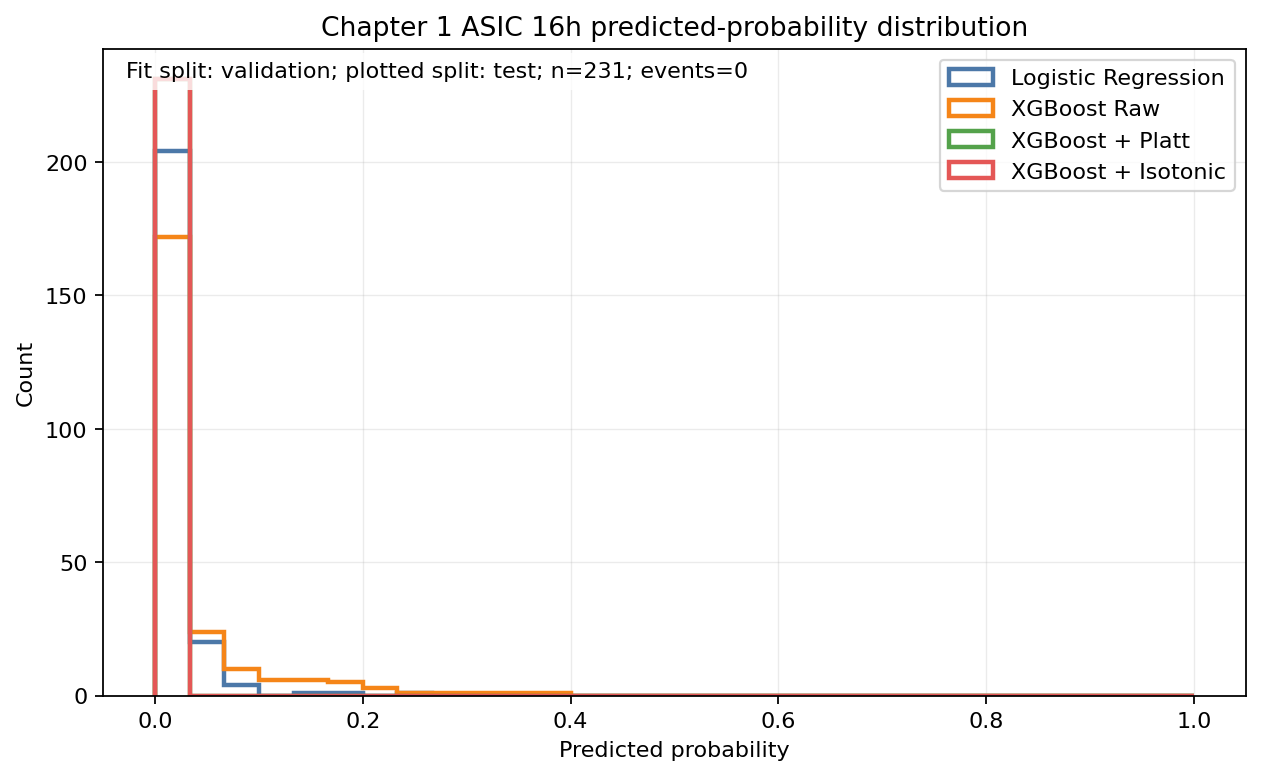

### Horizon 24h

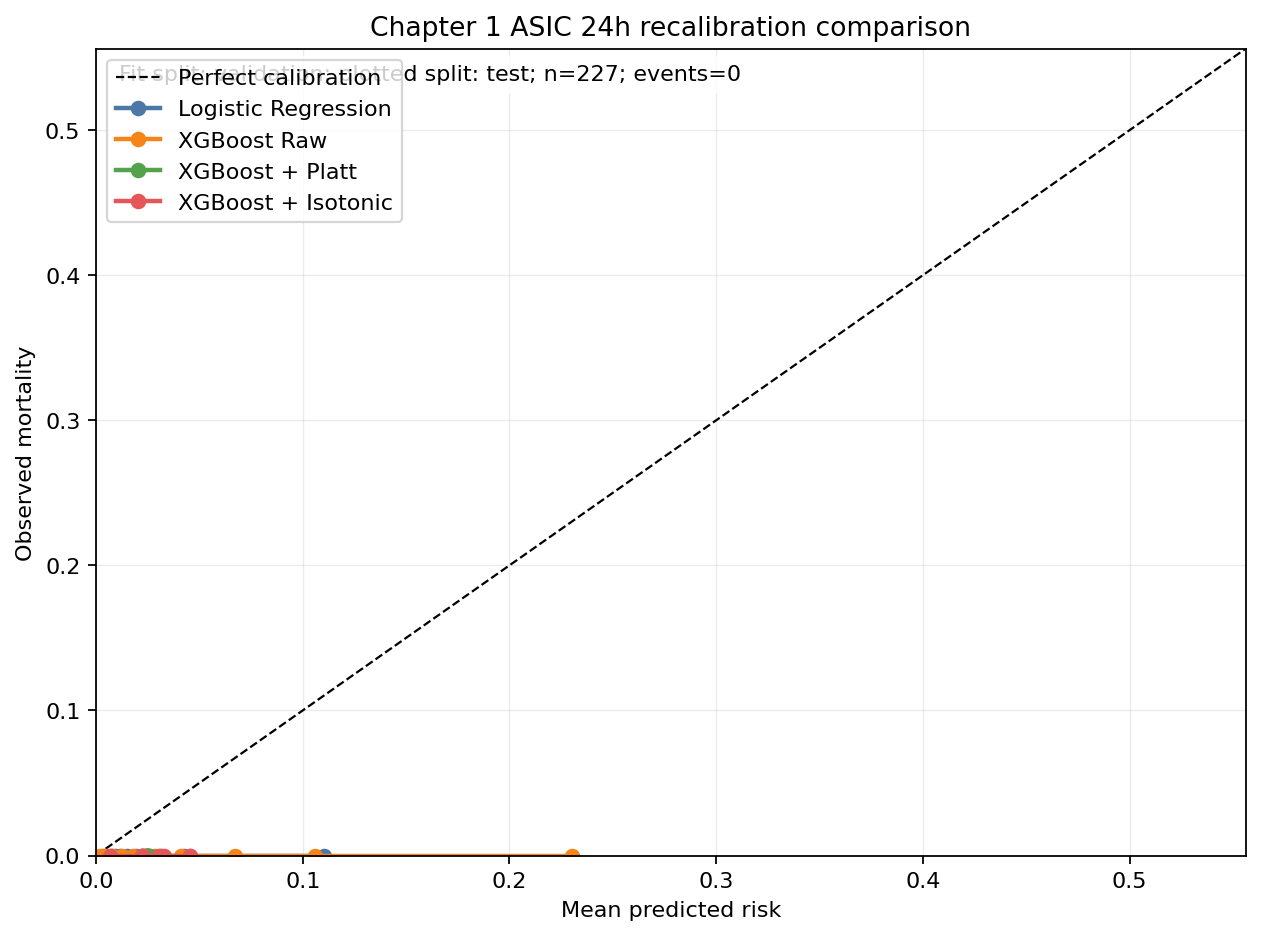

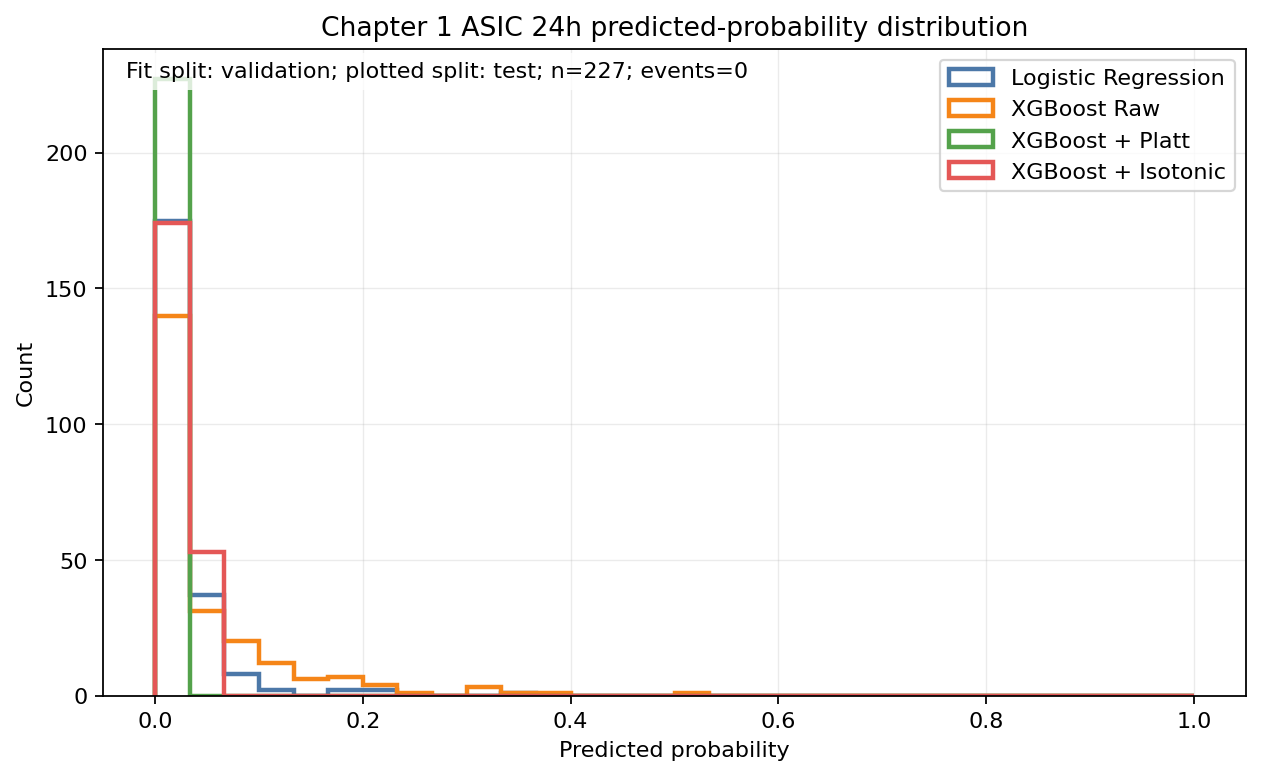

### Horizon 48h

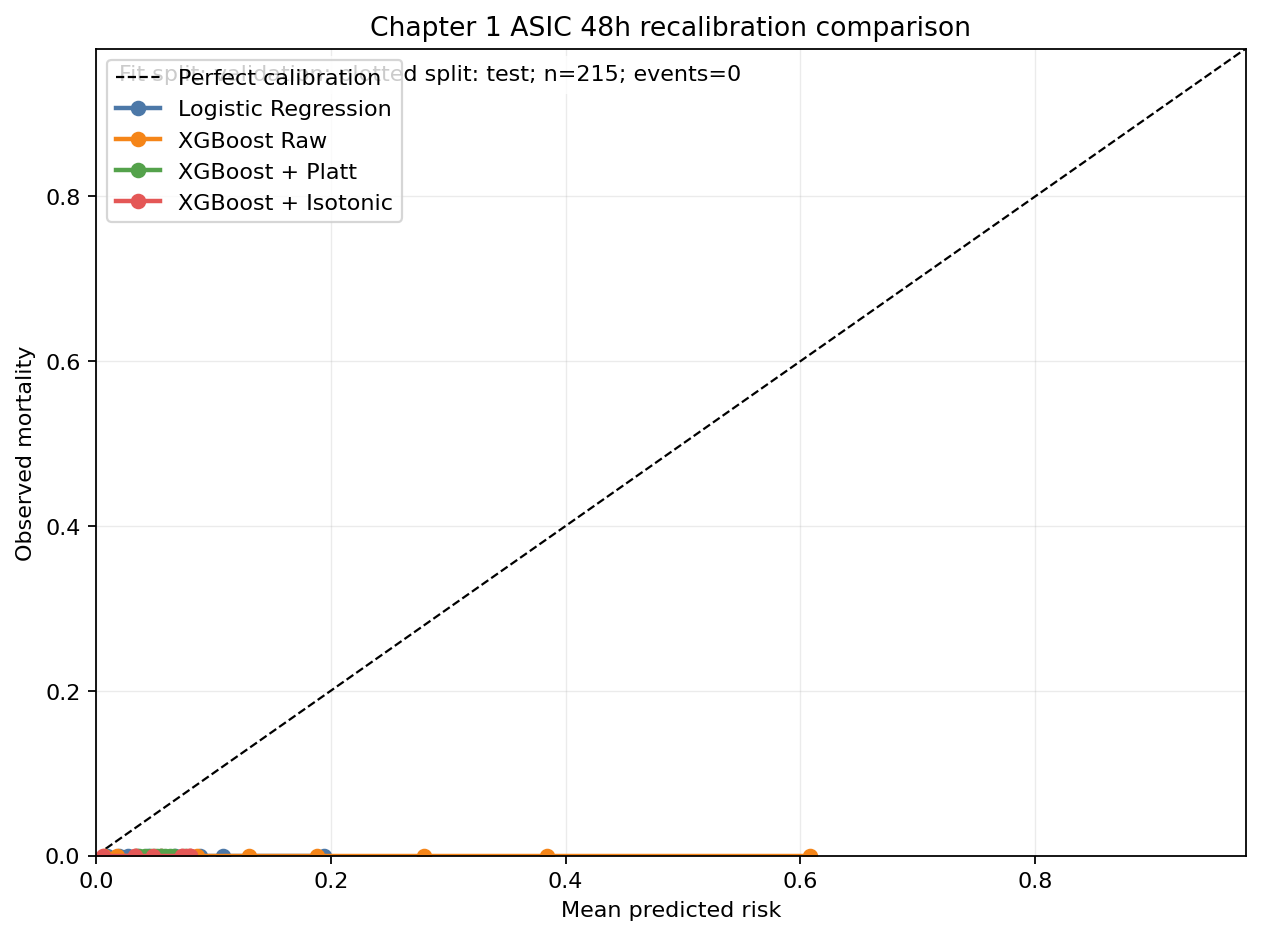

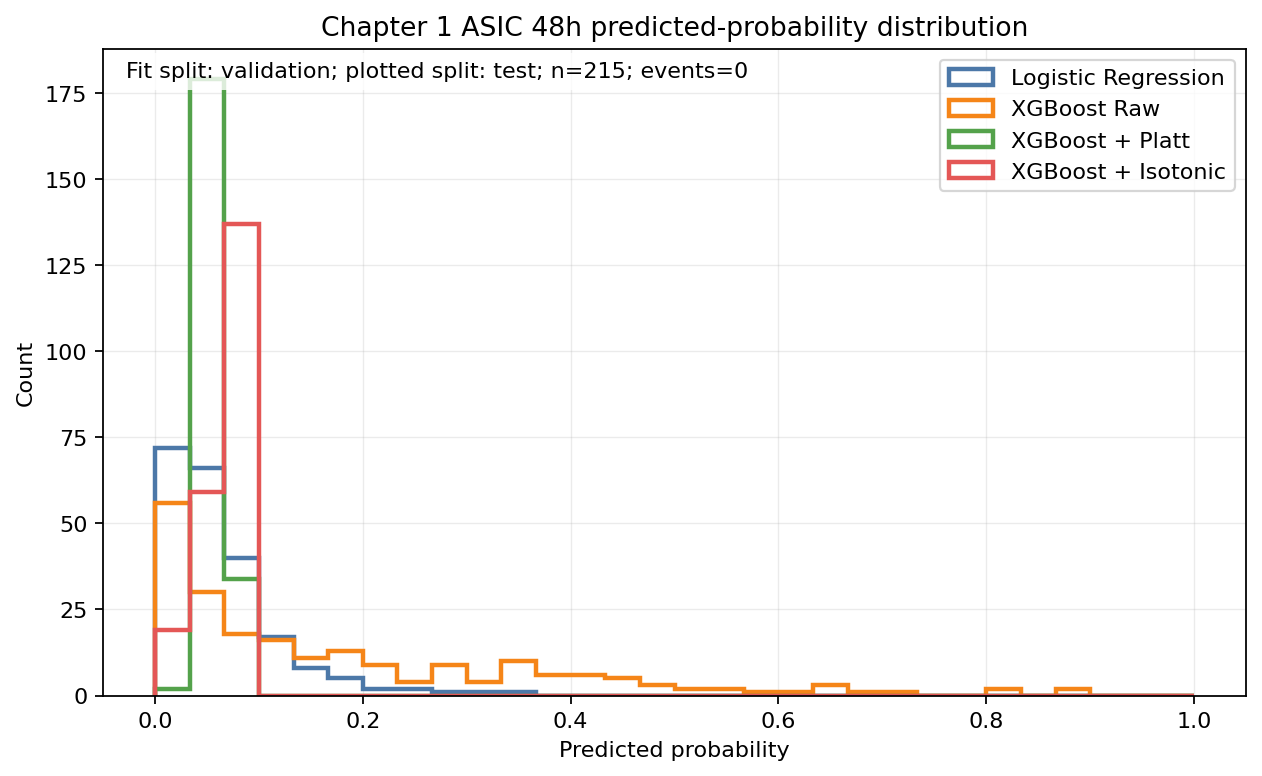

### Horizon 72h

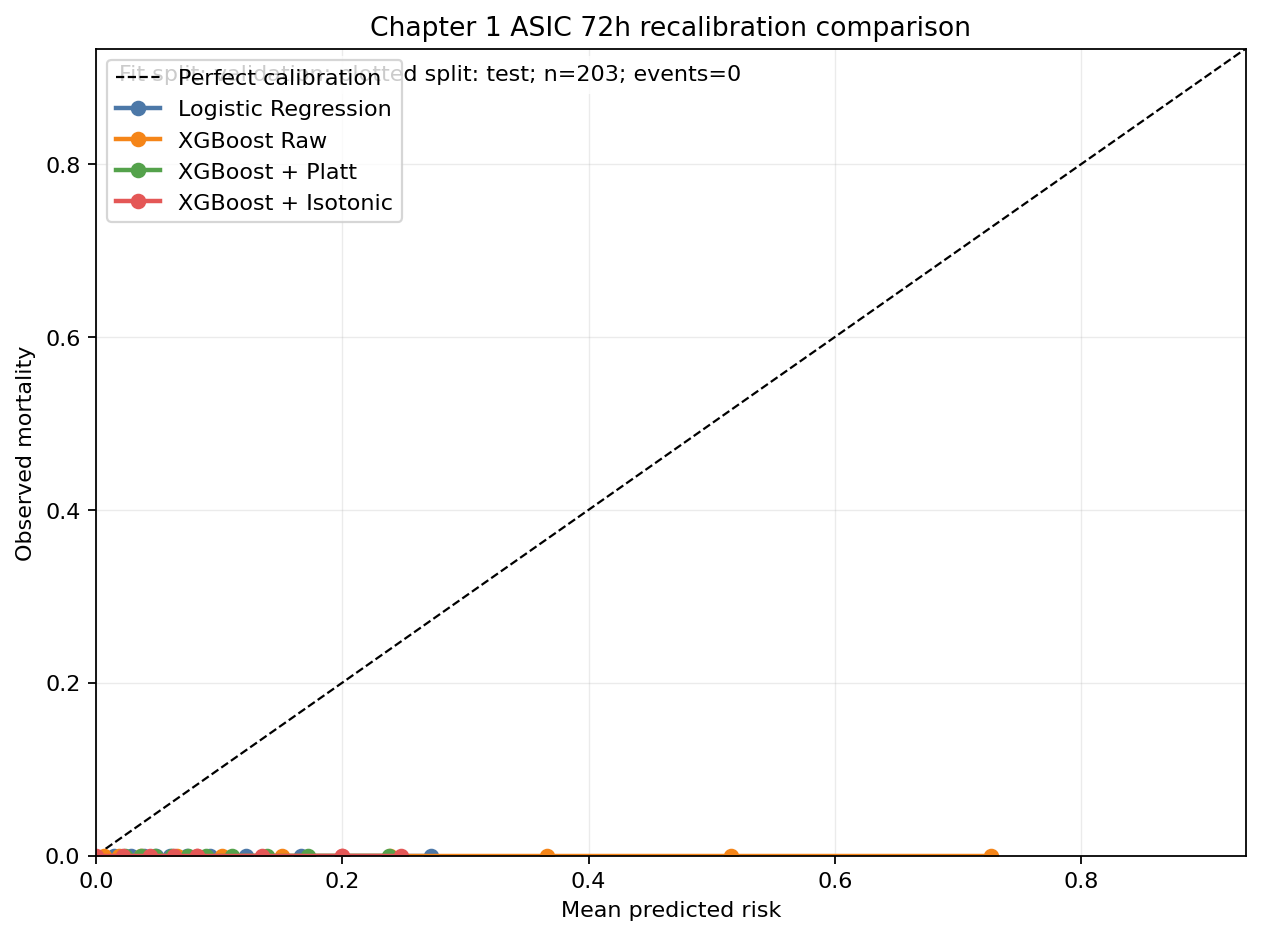

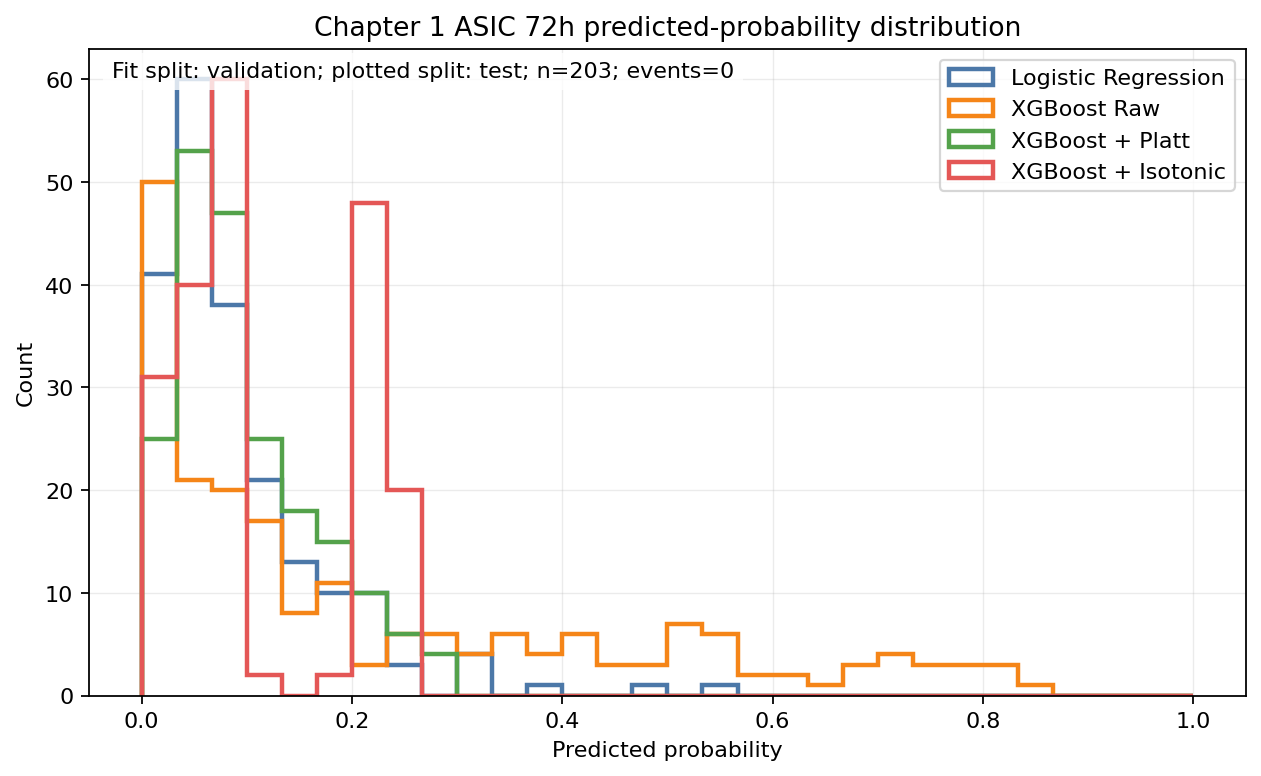

In [5]:
display(Markdown("### Cross-horizon summary figure"))
display(Image(filename=str(result.summary_figure_path)))

for horizon_result in result.horizon_results:
    display(Markdown(f"### Horizon {horizon_result.horizon_h}h"))
    display(Image(filename=str(horizon_result.reliability_plot_path)))
    display(Image(filename=str(horizon_result.probability_distribution_plot_path)))

## Interpretation Note

In [6]:
display(Markdown((result.interpretation_note_path).read_text()))

# Chapter 1 ASIC XGBoost Recalibration Review

Recalibration methods fit on `validation` only and applied unchanged to `test`.
Reference comparisons include Logistic Regression and raw XGBoost from the saved baseline prediction artifacts.

The currently available test artifacts are not binary-evaluable for any horizon.
On this local artifact bundle, the test split has no events, so AUROC, AUPRC, calibration slope, and calibration intercept are unavailable on test.
Brier score and reliability-style plots were still written, but full probability interpretation should wait for a binary-evaluable frozen test artifact set.

- 8h test: logistic Brier 0.0010, raw XGBoost Brier 0.0009, Platt Brier 0.0001, isotonic Brier 0.0002.
- 16h test: logistic Brier 0.0009, raw XGBoost Brier 0.0051, Platt Brier 0.0003, isotonic Brier 0.0005.
- 24h test: logistic Brier 0.0022, raw XGBoost Brier 0.0081, Platt Brier 0.0006, isotonic Brier 0.0009.
- 48h test: logistic Brier 0.0074, raw XGBoost Brier 0.0688, Platt Brier 0.0031, isotonic Brier 0.0041.
- 72h test: logistic Brier 0.0150, raw XGBoost Brier 0.1046, Platt Brier 0.0141, isotonic Brier 0.0184.

Preliminary interpretation:
- Recalibration can improve XGBoost probability outputs without changing the underlying ranking model, but the current local bundle is too sparse on test to make a strong chapter-level claim.
- Logistic regression should remain the primary Chapter 1 anchor unless the full evaluable ASIC test bundle shows recalibrated XGBoost delivers stable probability improvement without losing the expected discrimination advantage.